In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
import os
os.environ["OMP_NUM_THREADS"]= '7'

In [2]:
# upload the file
usedcars = pd.read_csv('automobile_dot_it_used_fiat_500_in_Italy_dataset_filtered.csv')

In [3]:
# data type & non-null values
usedcars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1538 entries, 0 to 1537
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   model            1538 non-null   object 
 1   engine_power     1538 non-null   int64  
 2   age_in_days      1538 non-null   int64  
 3   km               1538 non-null   int64  
 4   previous_owners  1538 non-null   int64  
 5   lat              1538 non-null   float64
 6   lon              1538 non-null   float64
 7   price            1538 non-null   int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 96.3+ KB


In [4]:
usedcars.describe(include='all')

,model,engine_power,age_in_days,km,previous_owners,lat,lon,price
count,1538,1538.000000,1538.000000,1538.000000,1538.000000,1538.000000,1538.000000,1538.000000
unique,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,lounge,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1094,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,51.904421,1650.980494,53396.011704,1.123537,43.541361,11.563428,8576.003901
std,NaN,3.988023,1289.522278,40046.830723,0.416423,2.133518,2.328190,1939.958641
min,NaN,51.000000,366.000000,1232.000000,1.000000,36.855839,7.245400,2500.000000
25%,NaN,51.000000,670.000000,20006.250000,1.000000,41.802990,9.505090,7122.500000
50%,NaN,51.000000,1035.000000,39031.000000,1.000000,44.394096,11.869260,9000.000000
75%,NaN,51.000000,2616.000000,79667.750000,1.000000,45.467960,12.769040,10000.000000


In [5]:
usedcars.head()

,model,engine_power,age_in_days,km,previous_owners,lat,lon,price
0,lounge,51,882,25000,1,44.907242,8.611560,8900
1,pop,51,1186,32500,1,45.666359,12.241890,8800
2,sport,74,4658,142228,1,45.503300,11.417840,4200
3,lounge,51,2739,160000,1,40.633171,17.634609,6000
4,pop,73,3074,106880,1,41.903221,12.495650,5700


In [6]:
#Check for Missing Data
usedcars.isnull().sum()

model              0
engine_power       0
age_in_days        0
km                 0
previous_owners    0
lat                0
lon                0
price              0
dtype: int64

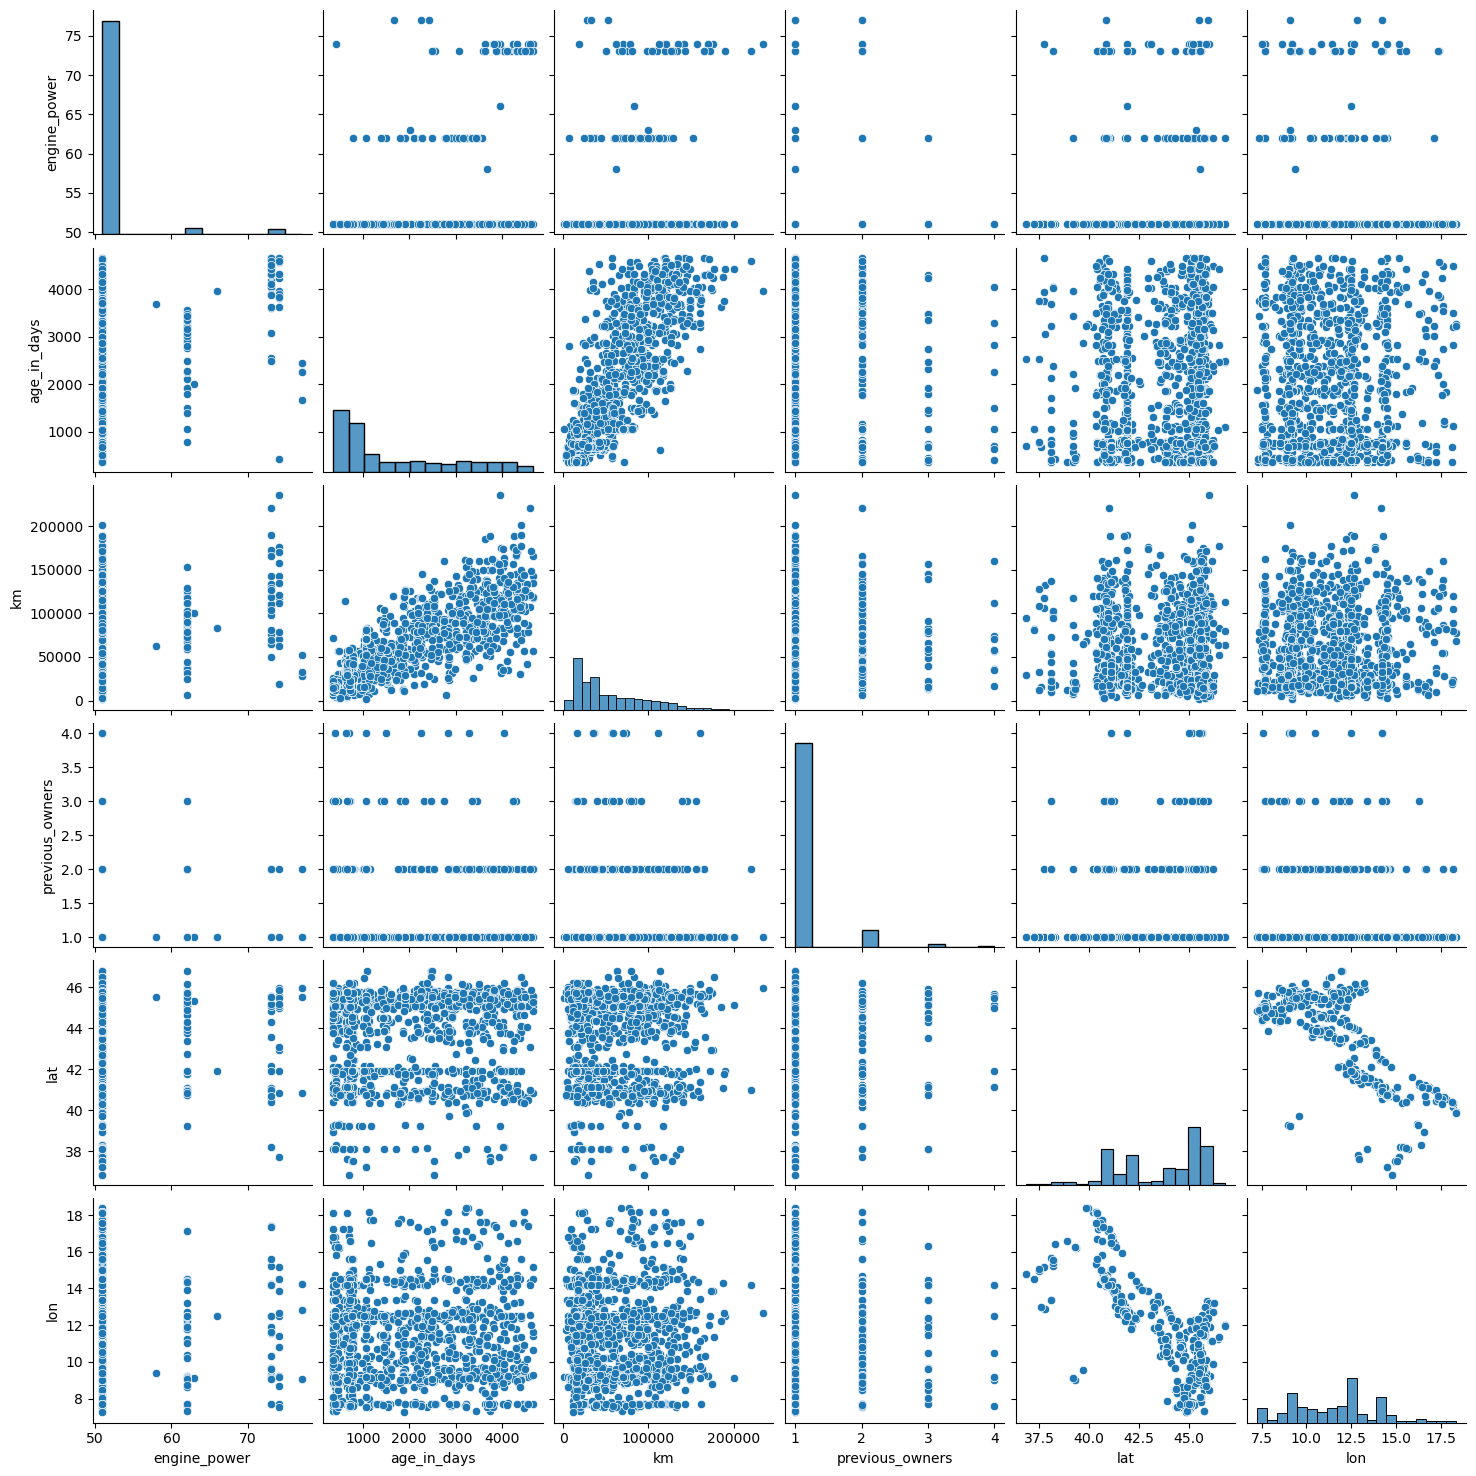

In [8]:
features = usedcars.iloc[:,1:7]
sns.pairplot(features)

In [9]:
# select an appropriate number for k
sc_features = StandardScaler()
features = sc_features.fit_transform(features)

C:\Users\44747\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\Users\44747\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\Users\44747\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\Users\44747\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

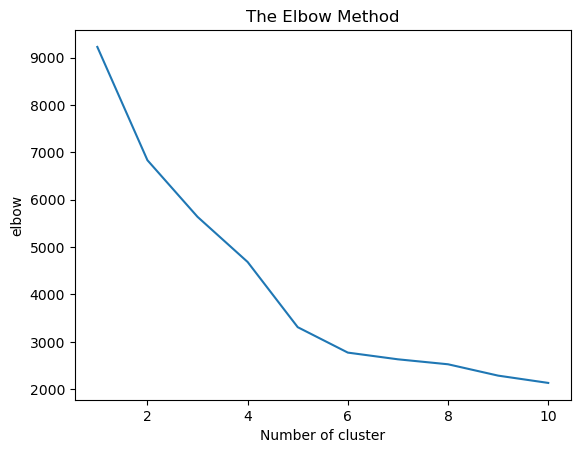

In [16]:
# using the elbow method to find the optimal number of the cluster
elbow= []
for i in range(1,11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 30)
    kmeans.fit(features)
    elbow.append(kmeans.inertia_)
plt.plot(range(1,11),elbow)
plt.title('The Elbow Method')
plt.xlabel('Number of cluster')
plt.ylabel('elbow')
plt.show()

In [28]:
# generate cluster
kmeans=KMeans(n_clusters=6, init='k-means++', random_state=30)
appliedkmeans = kmeans.fit_predict(features)

In [29]:
#fit the scatterplot dimensions
pca = PCA(n_components=2)
features_reduced = pca.fit_transform(features)
pca.explained_variance_ratio_

array([0.34054594, 0.29190703])

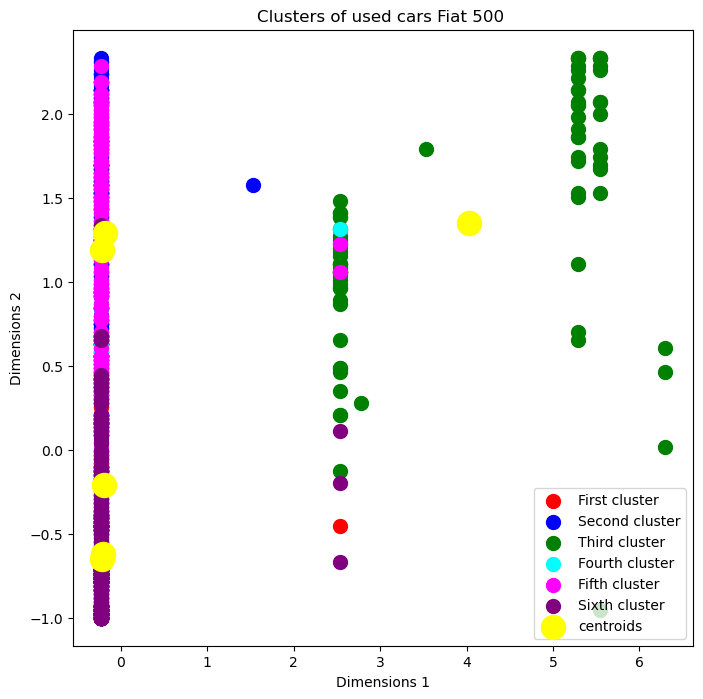

In [33]:
# show the scatterplot
plt.figure(figsize=(8,8))
plt.scatter(features[appliedkmeans==0,0],features[appliedkmeans==0,1], s= 100, c= 'red', label= 'First cluster')
plt.scatter(features[appliedkmeans==1,0],features[appliedkmeans==1,1], s= 100, c= 'blue', label= 'Second cluster')
plt.scatter(features[appliedkmeans==2,0],features[appliedkmeans==2,1], s= 100, c= 'green', label= 'Third cluster')
plt.scatter(features[appliedkmeans==3,0],features[appliedkmeans==3,1], s= 100, c= 'cyan', label= 'Fourth cluster')
plt.scatter(features[appliedkmeans==4,0],features[appliedkmeans==4,1], s= 100, c= 'magenta', label= 'Fifth cluster')
plt.scatter(features[appliedkmeans==5,0],features[appliedkmeans==5,1], s= 100, c= 'purple', label= 'Sixth cluster')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s= 300, c= 'yellow', label='centroids')
plt.title('Clusters of used cars Fiat 500 ')
plt.xlabel('Dimensions 1')
plt.ylabel('Dimensions 2')
plt.legend()
plt.show()

apply another aclustring algoritm Hierarchical Clustering
Hierarchical clustering is also a distance-based clustering method.

use a function from the Scipy package to visualise the dendrogram 
to select the number of clusters

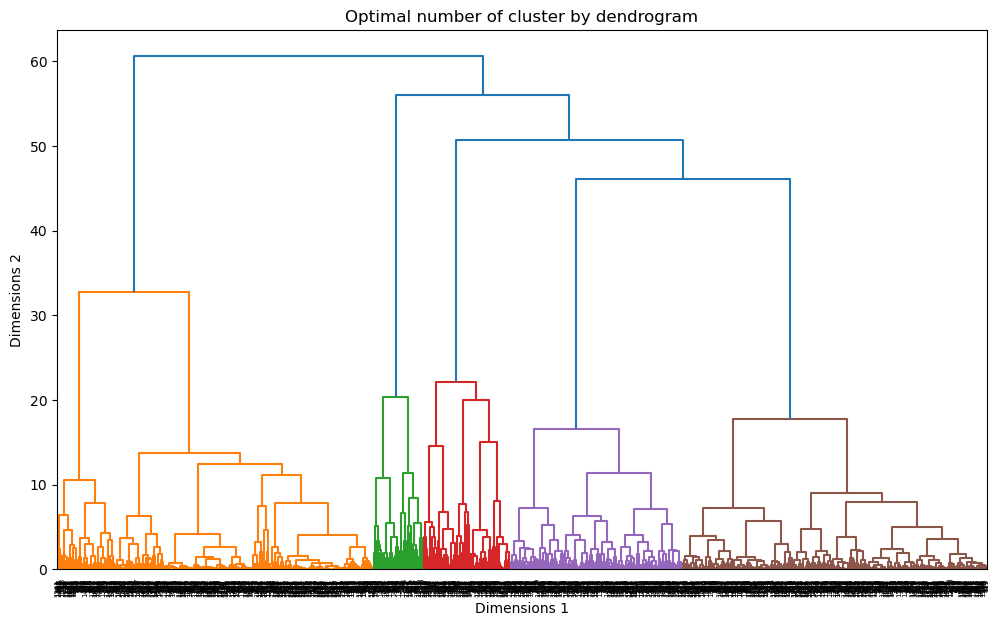

In [35]:
# find the optimal number of clusters by dendrogram
plt.figure(figsize=(12,7))
optimal_number = sch.dendrogram(sch.linkage(features, method = 'ward'))
plt.title('Optimal number of cluster by dendrogram')
plt.xlabel('Dimensions 1')
plt.ylabel('Dimensions 2')
plt.show()

In [37]:
# apply hierarchical algoritm on dataset

hier_alg = AgglomerativeClustering(n_clusters= 6, metric = 'euclidean', linkage= 'ward')
applied_hier_alg= hier_alg.fit_predict(features)
applied_hier_alg

array([1, 1, 2, ..., 4, 4, 5])

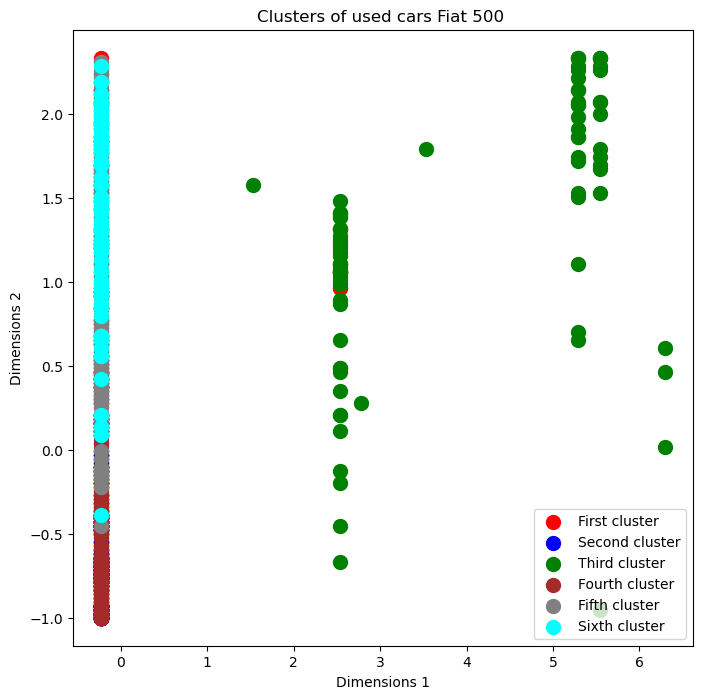

In [38]:
# hierarchical algoritm scatterplot
plt.figure(figsize=(8,8))
plt.scatter(features[applied_hier_alg==0,0],features[applied_hier_alg==0,1], s= 100, c= 'red', label= 'First cluster')
plt.scatter(features[applied_hier_alg==1,0],features[applied_hier_alg==1,1], s= 100, c= 'blue', label= 'Second cluster')
plt.scatter(features[applied_hier_alg==2,0],features[applied_hier_alg==2,1], s= 100, c= 'green', label= 'Third cluster')
plt.scatter(features[applied_hier_alg==3,0],features[applied_hier_alg==3,1], s= 100, c= 'brown', label= 'Fourth cluster')
plt.scatter(features[applied_hier_alg==4,0],features[applied_hier_alg==4,1], s= 100, c= 'gray', label= 'Fifth cluster')
plt.scatter(features[applied_hier_alg==5,0],features[applied_hier_alg==5,1], s= 100, c= 'cyan', label= 'Sixth cluster')
plt.title('Clusters of used cars Fiat 500 ')
plt.xlabel('Dimensions 1')
plt.ylabel('Dimensions 2')
plt.legend()
plt.show()